# Red Neuronal
Predicción de ataques cardiaco

In [20]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
import keras
from keras.models import Sequential 
from keras.layers import Dense, Dropout
import pandas as pd
import numpy as np


In [21]:
datos=pd.read_csv("heart_attack.csv")

In [22]:
datos.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


## Paso 1:  Preprocesamiento de los datos

In [23]:
# Seleccionamos los atributos y el target
y=datos["output"]
del datos ["output"]
X=datos

In [24]:
X.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa'],
      dtype='object')

In [25]:
y.value_counts()

1    165
0    138
Name: output, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=1234)

In [27]:
# Las variables continuas las vamos a estandarizar y las variables categóricas las vamos a binarizar
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
colum_trans=make_column_transformer(
    (OneHotEncoder(drop="first"), ['sex','cp','fbs','restecg','exng']),
    (StandardScaler(),['age','trtbps','chol','thalachh','caa'] )
)

In [28]:
X_train=colum_trans.fit_transform(X_train)
X_test=colum_trans.transform(X_test)

# Paso 2. Definir la arquitectura de la red

In [30]:
modelo=Sequential()
modelo.add(Dense(units=64,input_dim=X_train.shape[1], activation="relu"))  # Primer capa oculta
modelo.add(Dropout(0.35))
modelo.add(Dense(units=32,activation="relu"))  # Segunda capa oculta
modelo.add(Dropout(0.15))
modelo.add(Dense(units=1,activation="sigmoid"))  # Capa salida
modelo.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                896       
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,009
Trainable params: 3,009
Non-trainable params: 0
_________________________________________________________________


In [31]:
# Paso 3. Compilar el modelo
modelo.compile(loss="binary_crossentropy", optimizer="adam", metrics="Recall")

In [32]:
# paso 4. Entrenar el modelo
historial=modelo.fit(X_train,y_train,epochs=100, batch_size=32, validation_data=(X_test,y_test),verbose=False)
historial

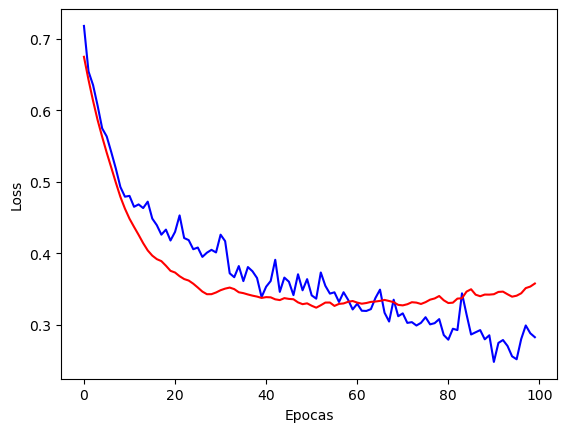

In [33]:
import matplotlib.pyplot as plt
plt.plot(historial.history["loss"], color="blue", label="Train")
plt.plot(historial.history["val_loss"], color="red", label="Test")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.show()

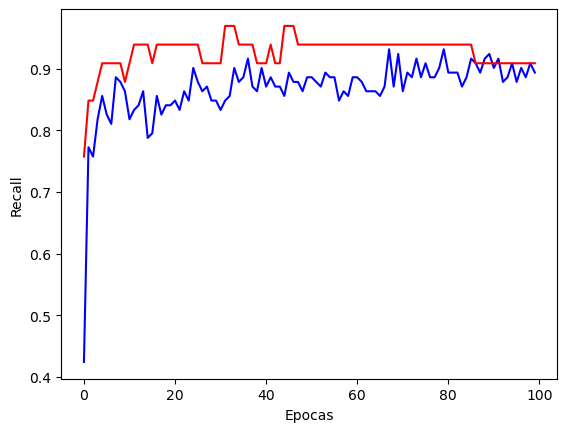

In [34]:
plt.plot(historial.history["recall"], color="blue", label="Train")
plt.plot(historial.history["val_recall"], color="red", label="Test")
plt.xlabel("Epocas")
plt.ylabel("Recall")
plt.show()